## State Estimation (With data from publicly available dataset Leg-KILO)

https://github.com/ouguangjun/legkilo-dataset

Not existing:
- contact_forces (maybe in joint_foot last 4 of effort)
- contact_state (can be estimated as contact_state = force > threshold)

Interesting topics:
- **/high_state** (contains position and velocity estimation of unitree)

In [1]:
%load_ext autoreload
%autoreload 2

In [54]:
from pathlib import Path
from utils.ekf_utils import *
from utils.legkilo_reader import *
from utils.plot_data import *

#### Read ROS and Ground truth file

In [34]:
legkilo_reader = LegKILOReader(rosbag_path="../custom_datasets/corridor.bag",
                               gt_path="../custom_datasets/corridor_tum.txt",
                               output_dir="../results/leg-kilo",
                               file_name="legkilo-data_corridor")

Reading ground truth from ../custom_datasets/corridor_tum.txt
Loading data from ../results/leg-kilo/legkilo-data_corridor.npz


In [ ]:
legkilo_reader.inspect_rosbag_file()

#### Leg KILO plots

In [ ]:
leg_kilo_data = legkilo_reader.legkilo_data

force_np = np.array(leg_kilo_data["foot_force"])
time_state = np.array(leg_kilo_data["time_state"])
time_state -= time_state[0]

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10,10))

for i in range(4):
    axs[i].plot(time_state[10000:11000], force_np[10000:11000, i])
    axs[i].set_ylabel(f'Foot {i}')

axs[-1].set_xlabel('Time [s]')

# plt.tight_layout()
plt.show()

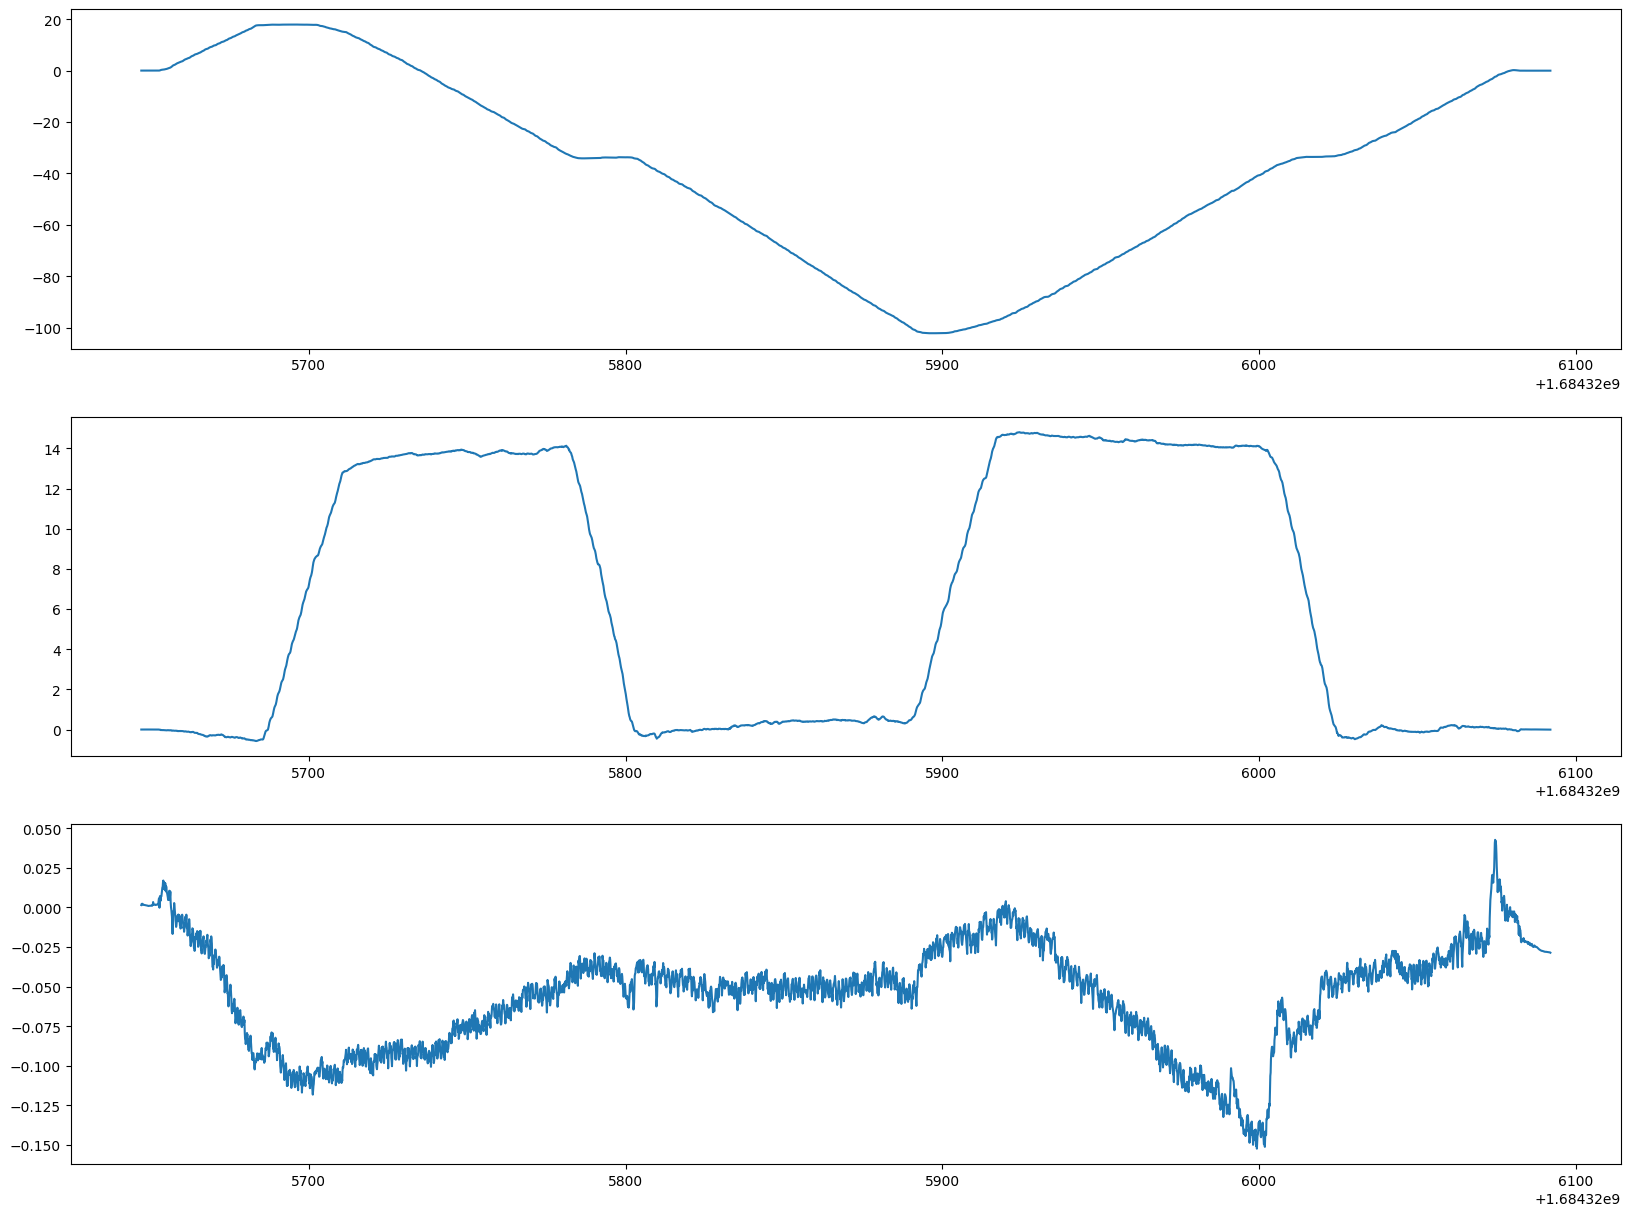

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(20,15))
for i in range(3):
    axes[i].plot(legkilo_reader.gt_timestamps, legkilo_reader.gt_positions[:, i])

plt.show()

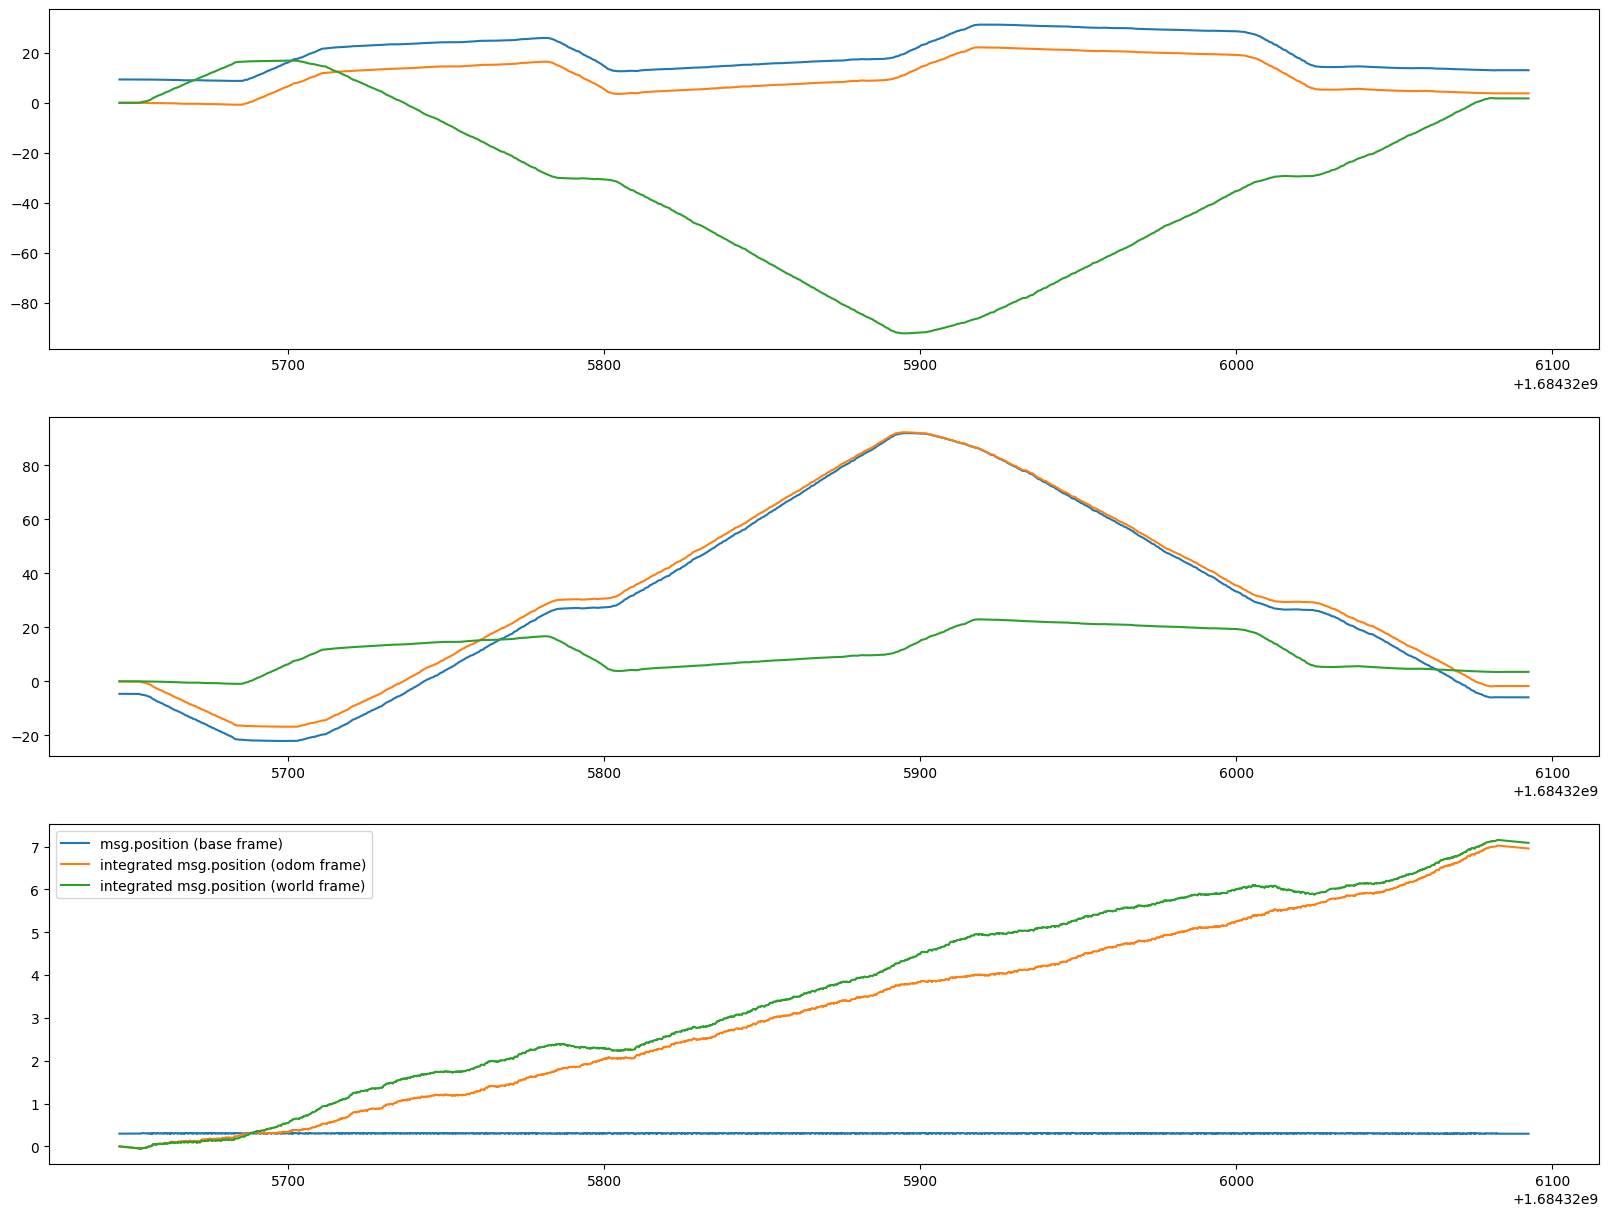

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(20,15))
for i in range(3):
    axes[i].plot(leg_kilo_data["time_state"], leg_kilo_data["base_pos_b"][:, i], label="msg.position (base frame)")
    axes[i].plot(leg_kilo_data["time_state"], leg_kilo_data["base_pos_o"][:, i], label="integrated msg.position (odom frame)")
    axes[i].plot(leg_kilo_data["time_state"], leg_kilo_data["base_pos_w"][:, i], label="integrated msg.position (world frame)")

plt.legend()
plt.show()

#### State Estimation

In [ ]:
start = 0
end = 10000

mean_dt = np.round(np.mean(leg_kilo_data["dt"][start:end]))
leg_kilo_data = legkilo_reader.legkilo_data
results_leg_kilo_est = run_state_estimation(dt=mean_dt,
                                            init_pos=leg_kilo_data["base_pos_o"][0],
                                            base_orient=leg_kilo_data['base_orient_quat'][start:end],
                                            base_ang_vel=leg_kilo_data['base_ang_vel'][start:end],
                                            joint_pos=leg_kilo_data['joint_pos'][start:end],
                                            joint_vel=leg_kilo_data['joint_vel'][start:end],
                                            joint_torque=leg_kilo_data['joint_torque'][start:end],
                                            contact_forces=leg_kilo_data['foot_force'][start:end],
                                            contact_pos=leg_kilo_data['contact_pos'][start:end],
                                            contact_state_threshold=200,
                                            Q=0.0001,
                                            R=[0.1, 0.1, 0.1])

Estimating base_acc.
Estimating contact state from contact_force and threshold


Estimating state:   0%|          | 0/10000 [00:00<?, ?it/s]

Estimating contact_force from estimated contact_state and joint torque


Estimating state: 100%|██████████| 10000/10000 [00:21<00:00, 462.98it/s]


In [62]:
# convert state estimation results to world/map frame
pos_update_w = legkilo_reader.convert_odom_to_map(odom_data=results_leg_kilo_est["pos_update"], 
                                                   first_quat=leg_kilo_data["base_orient_quat"][0],
                                                   with_offset=True)

vel_update_w = legkilo_reader.convert_odom_to_map(odom_data=results_leg_kilo_est["vel_update"],
                                                   first_quat=leg_kilo_data["base_orient_quat"][0],
                                                   with_offset=False)

### Unitree Estimation vs Kalman Filter

#### Base Vel

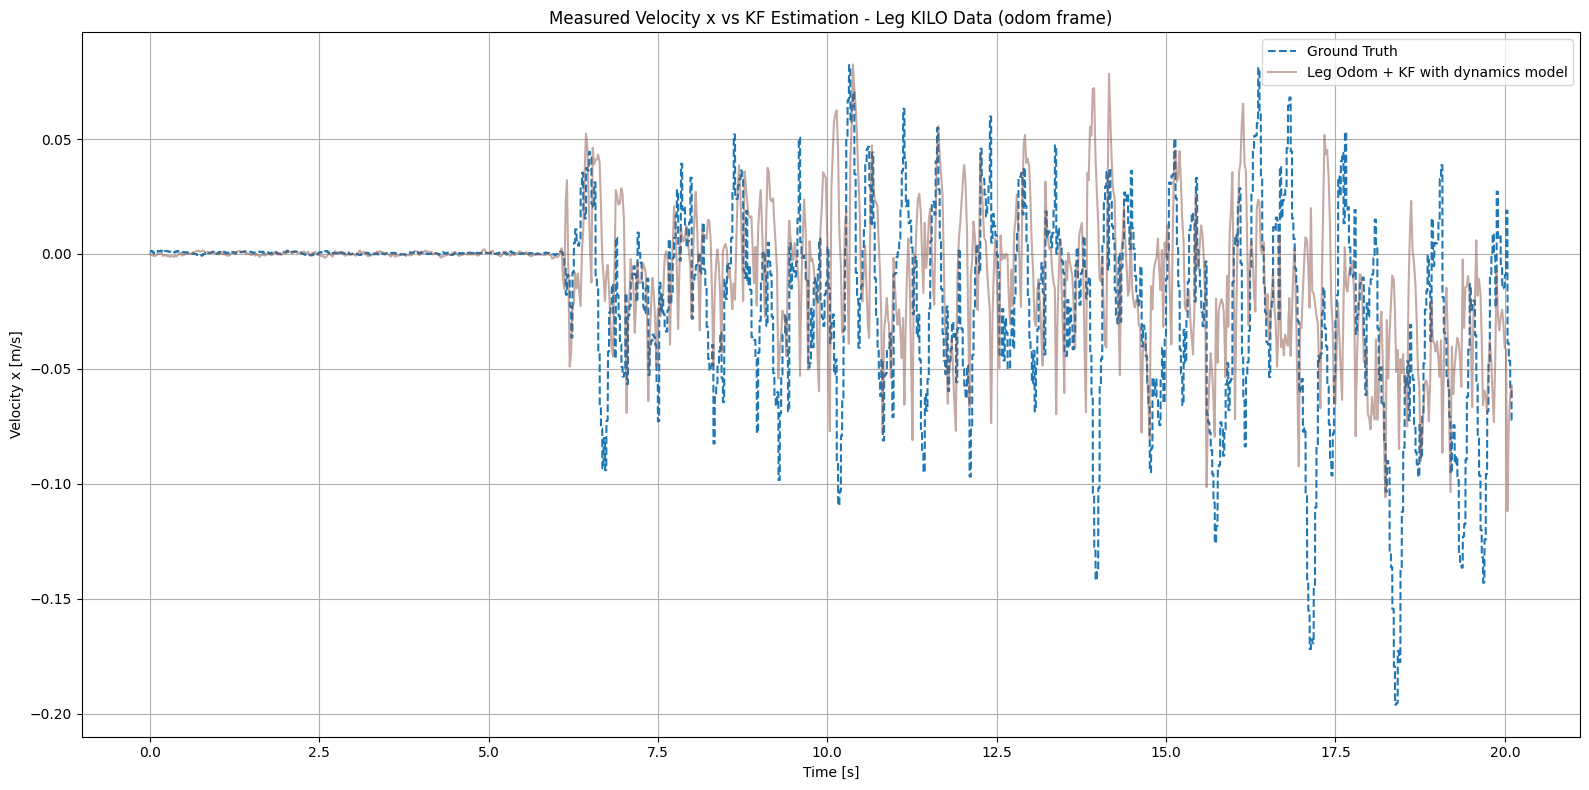

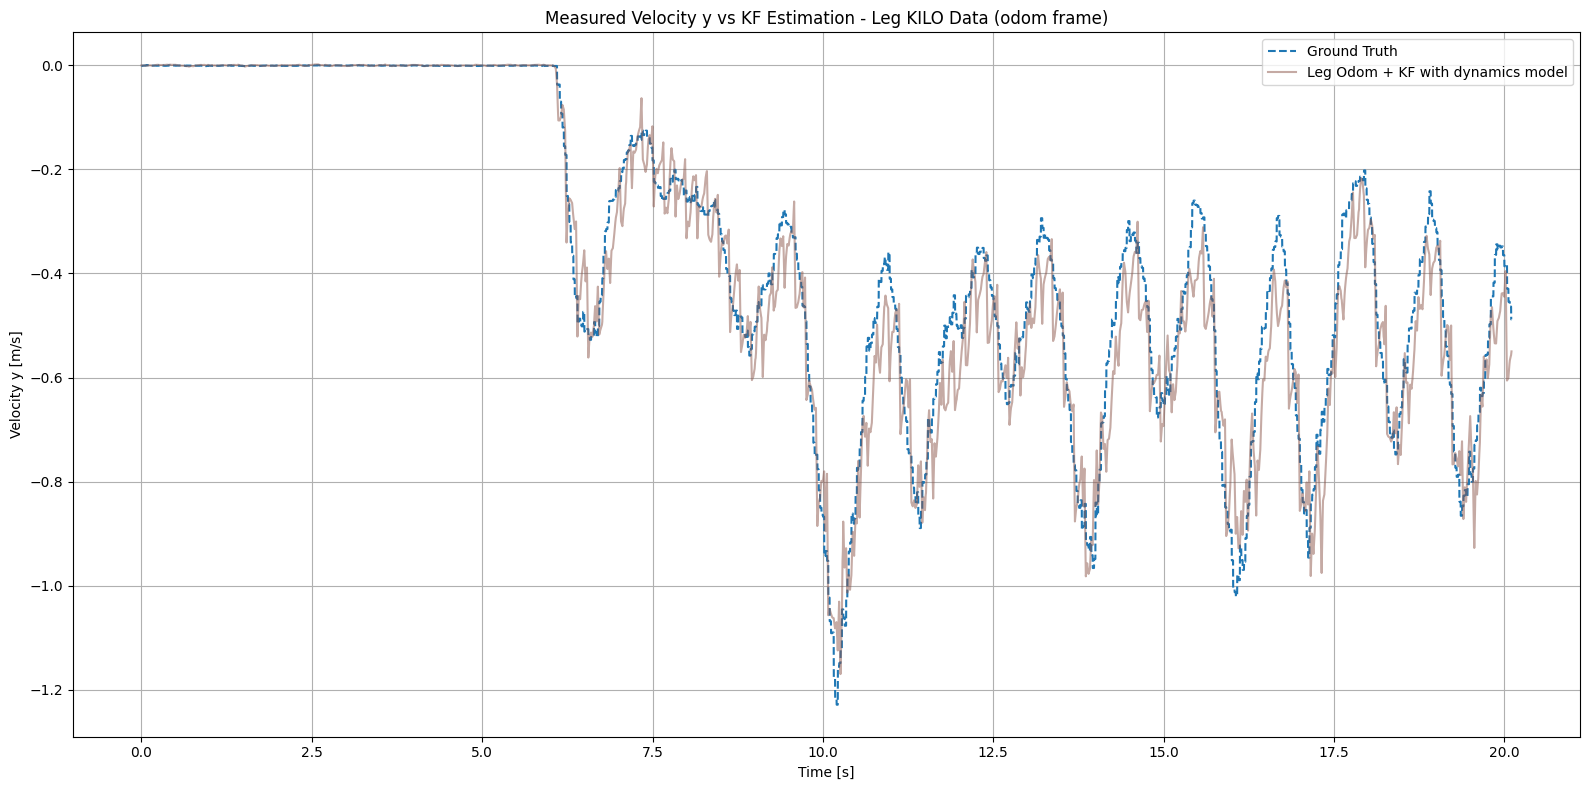

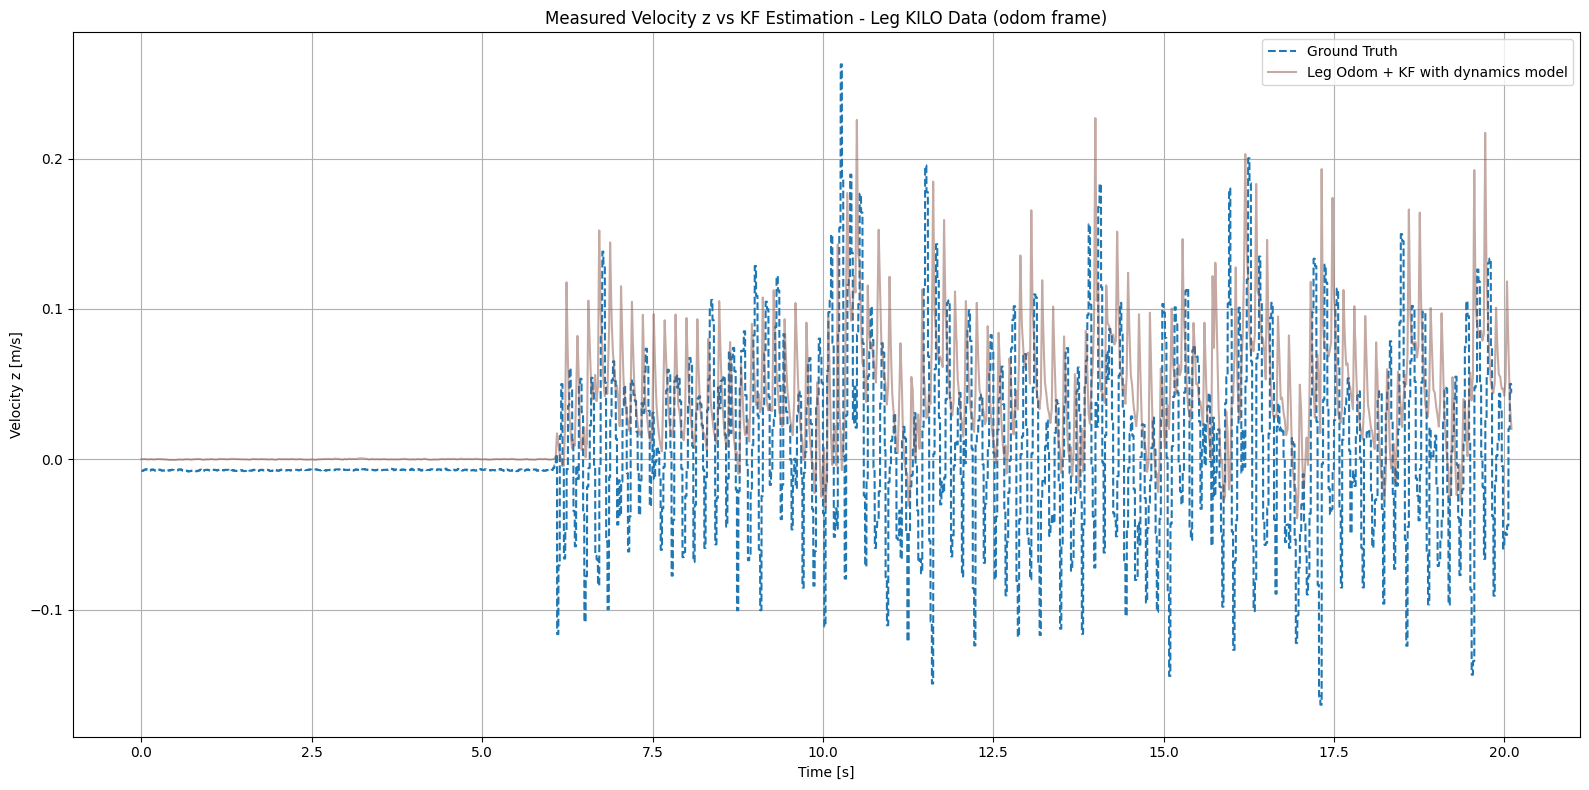

In [ ]:
# Odom frame

colors = ['#1f77b4', # gt
        # '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
time_state = leg_kilo_data["time_state"]
time_state -= time_state[0]

num_data_points = 10000

for i in range(len(dim)):
    gt_values = leg_kilo_data["base_vel_o"][:num_data_points, i:i+1]

    pred_values = [results_leg_kilo_est["vel_update"][:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=time_state[:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Leg KILO Data (odom frame)",
                            colors=colors
                            )

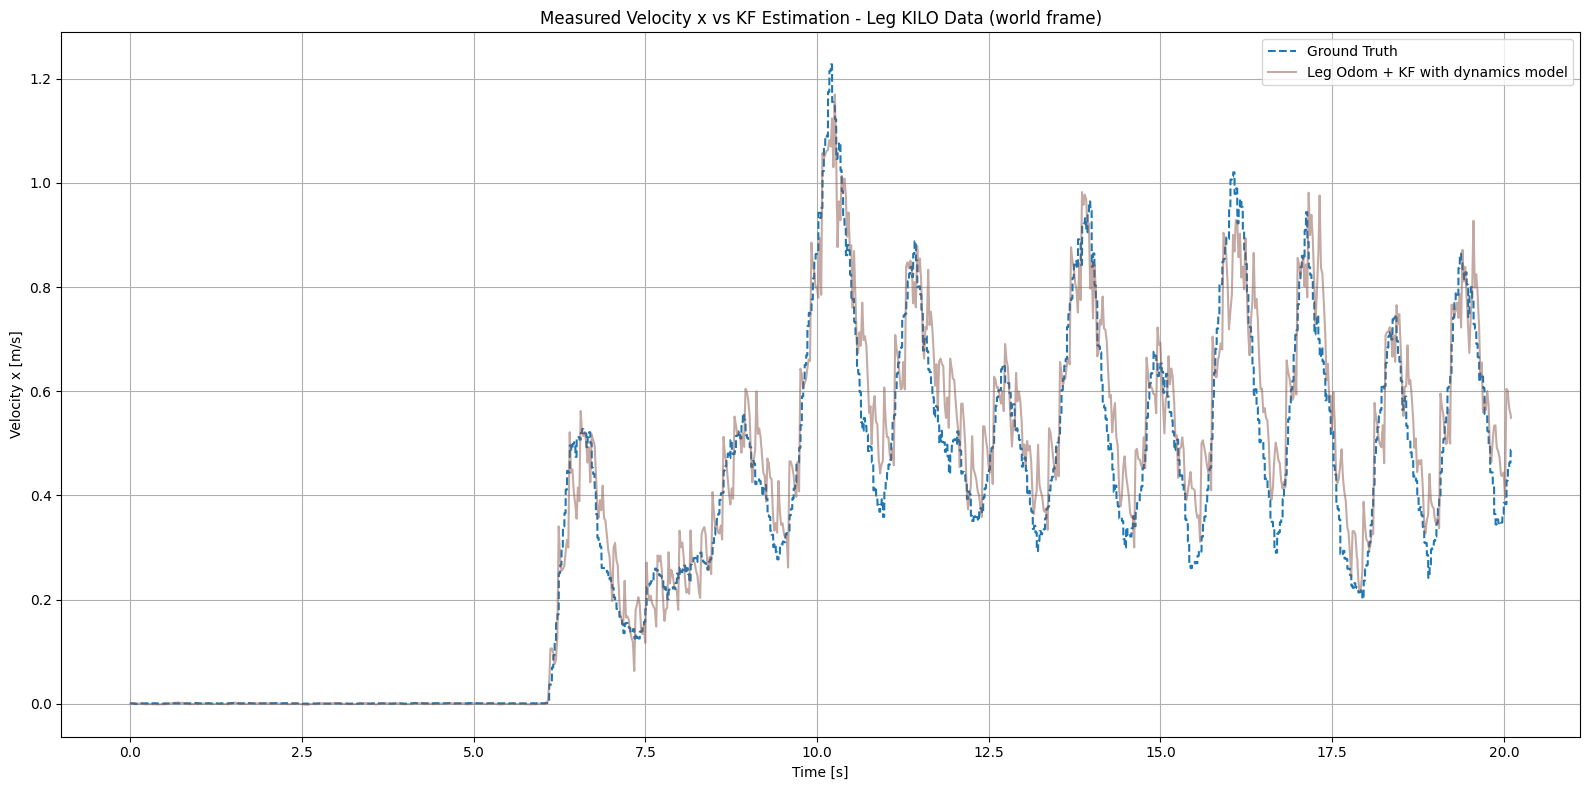

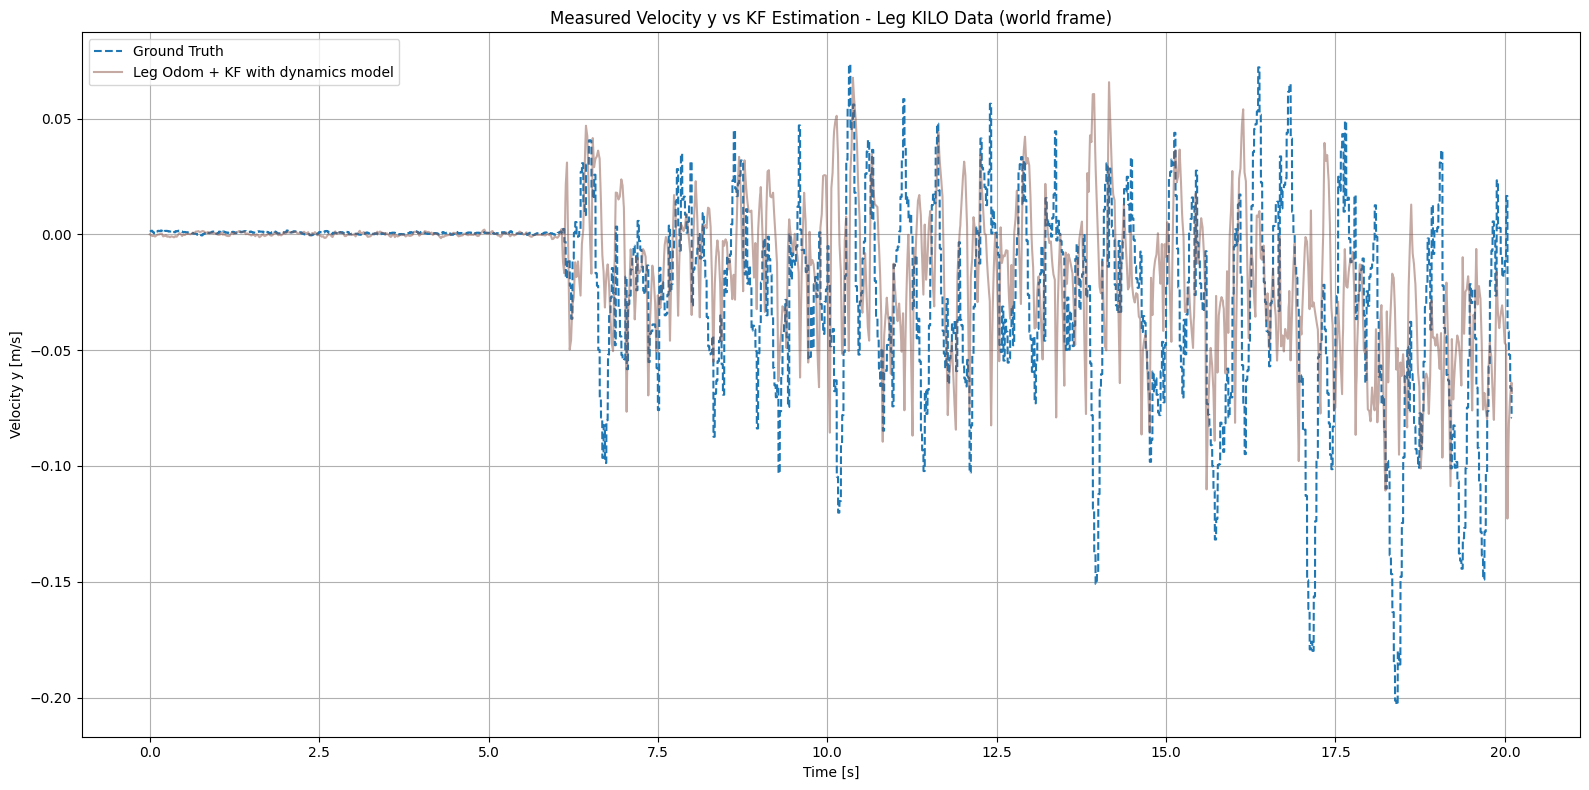

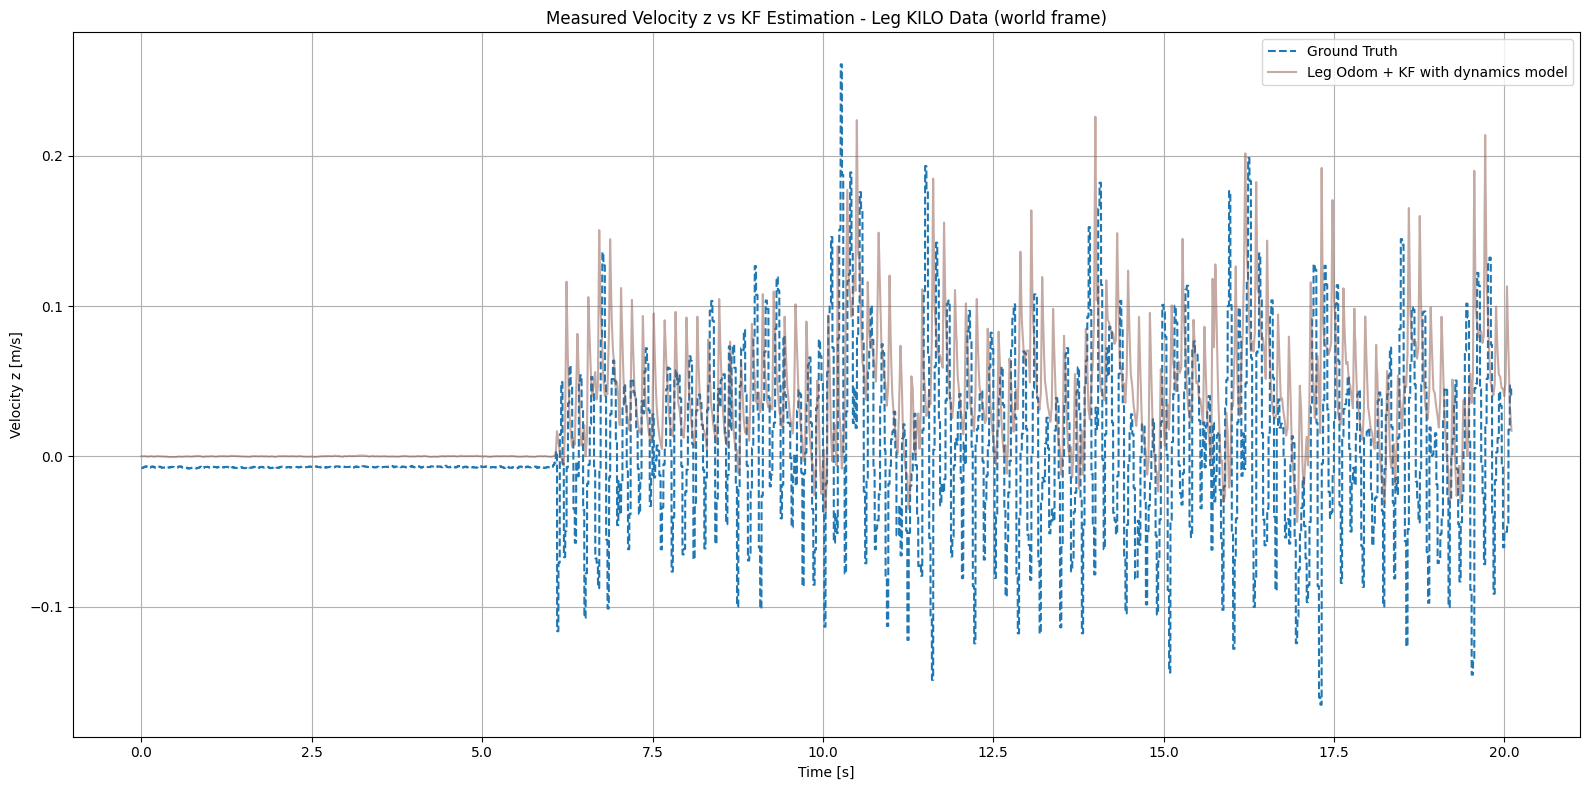

In [ ]:
colors = ['#1f77b4', # gt
        # '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
time_state = leg_kilo_data["time_state"]
time_state -= time_state[0]

num_data_points = 10000

for i in range(len(dim)):
    gt_values = leg_kilo_data["base_vel_w"][:num_data_points, i:i+1]

    pred_values = [vel_update_w[:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=time_state[:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Leg KILO Data (world frame)",
                            colors=colors
                            )

#### Base Pos

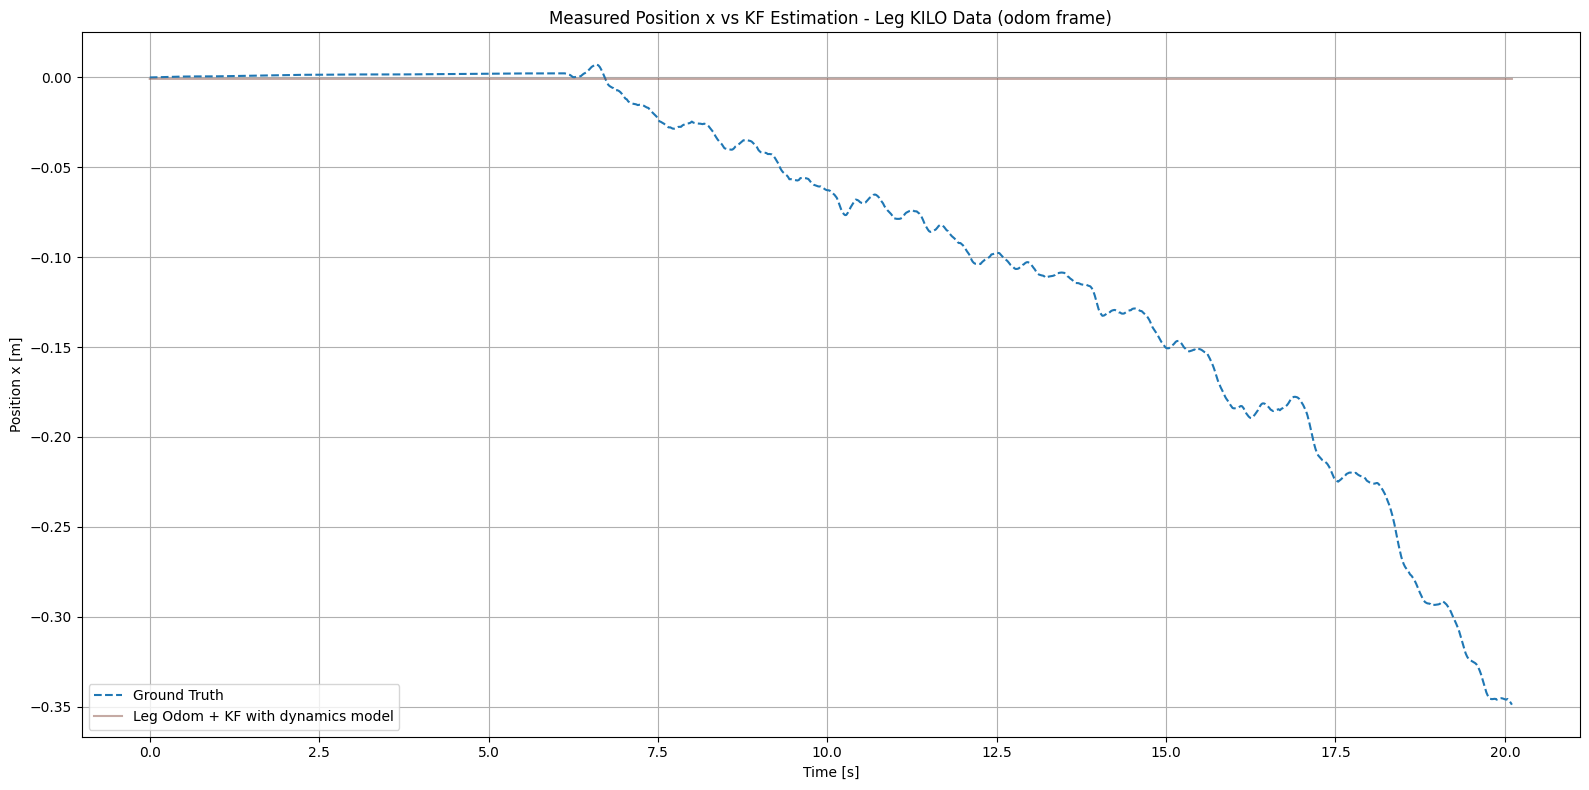

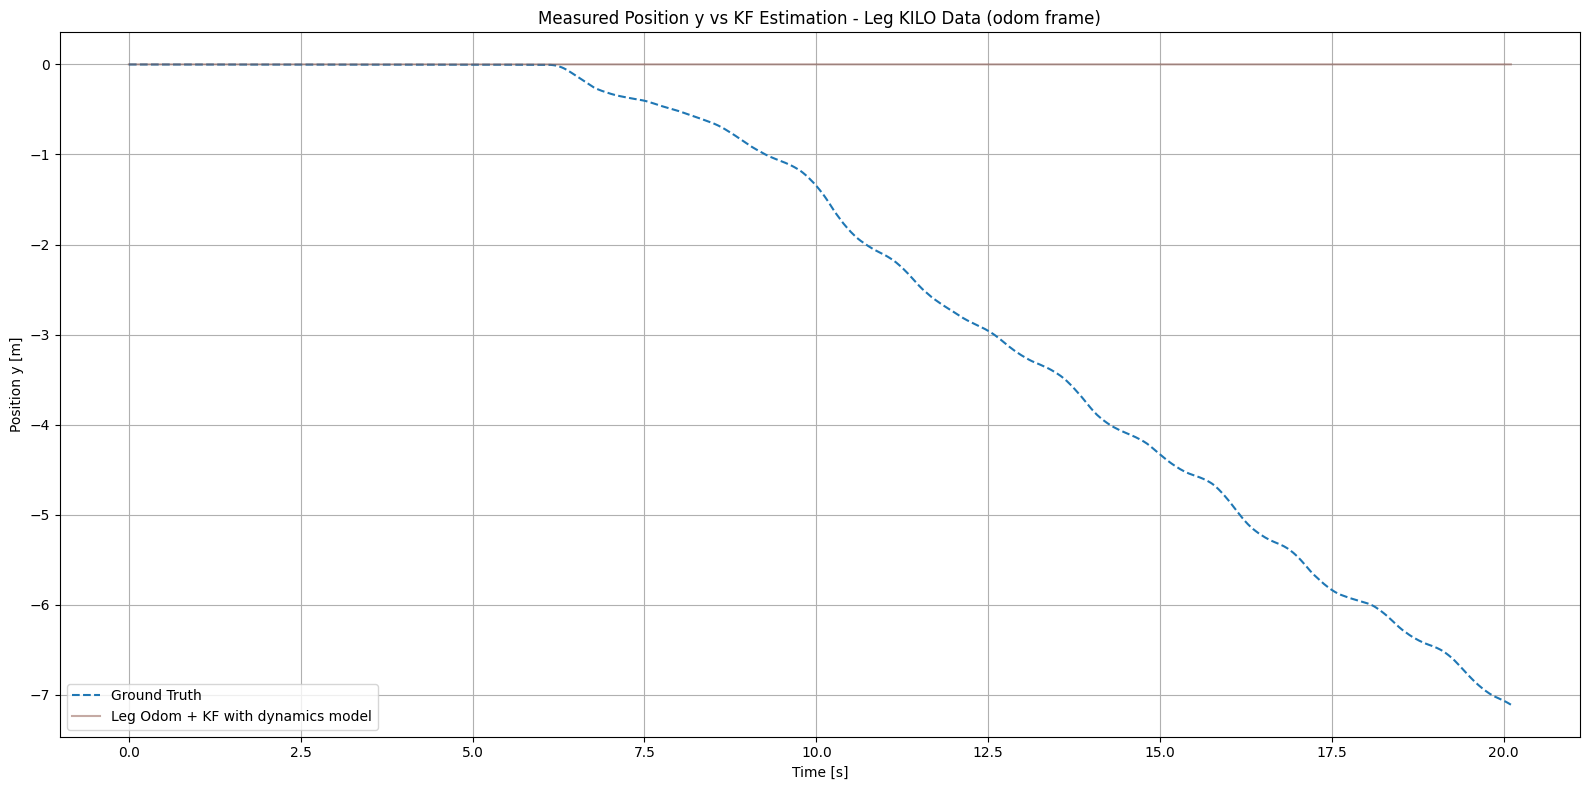

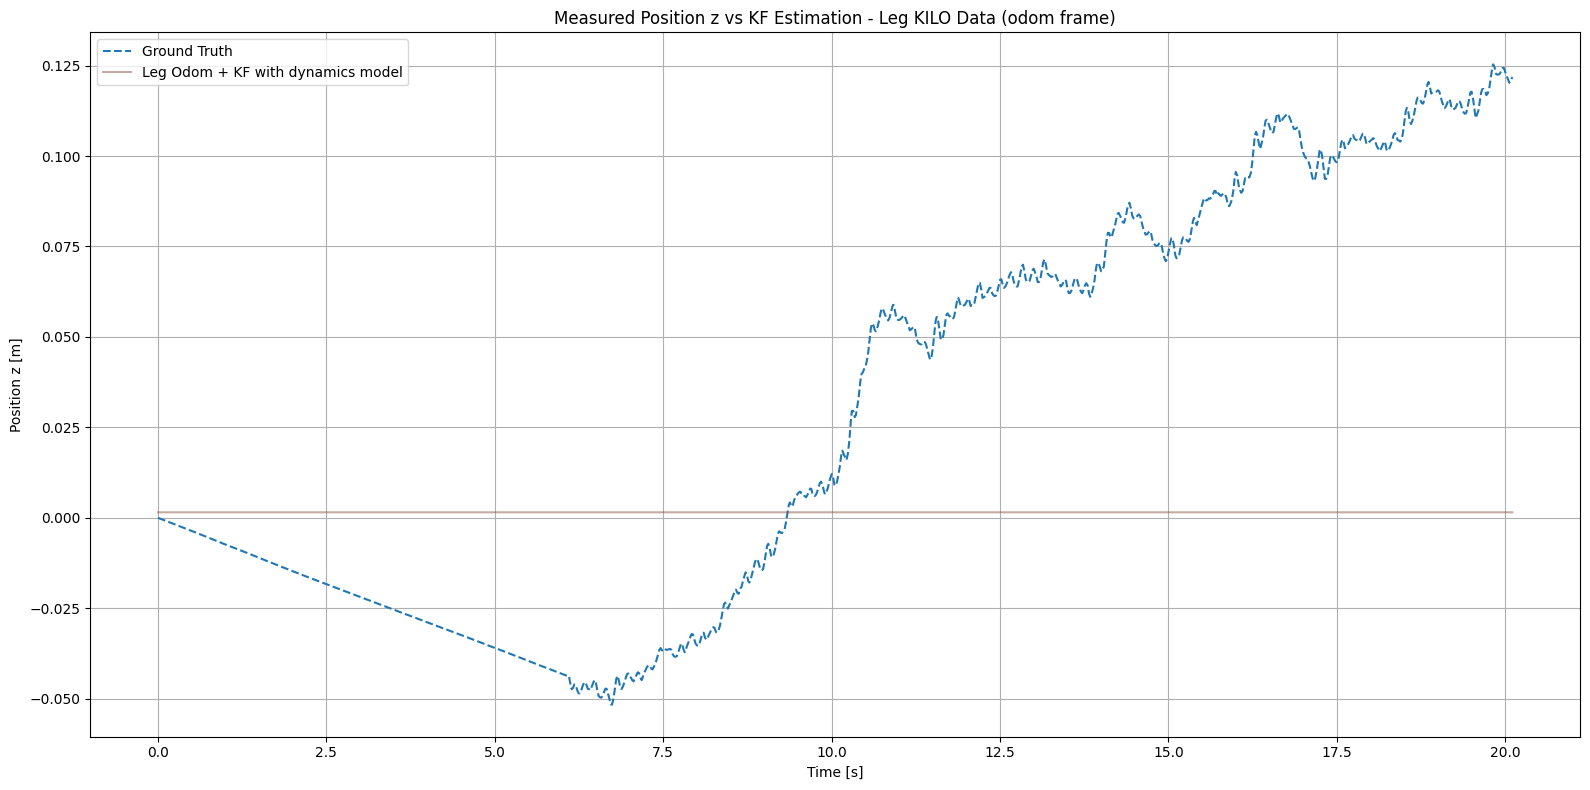

In [63]:
colors = ['#1f77b4', # gt
        # '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
time_state = leg_kilo_data["time_state"]
time_state -= time_state[0]

num_data_points = 10000

for i in range(len(dim)):
    gt_values = leg_kilo_data["base_pos_o"][:num_data_points, i:i+1]

    pred_values = [results_leg_kilo_est["pos_update"][:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=time_state[:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Position {dim[i]} [m]",
                            title=f"Measured Position {dim[i]} vs KF Estimation - Leg KILO Data (odom frame)",
                            colors=colors
                            )

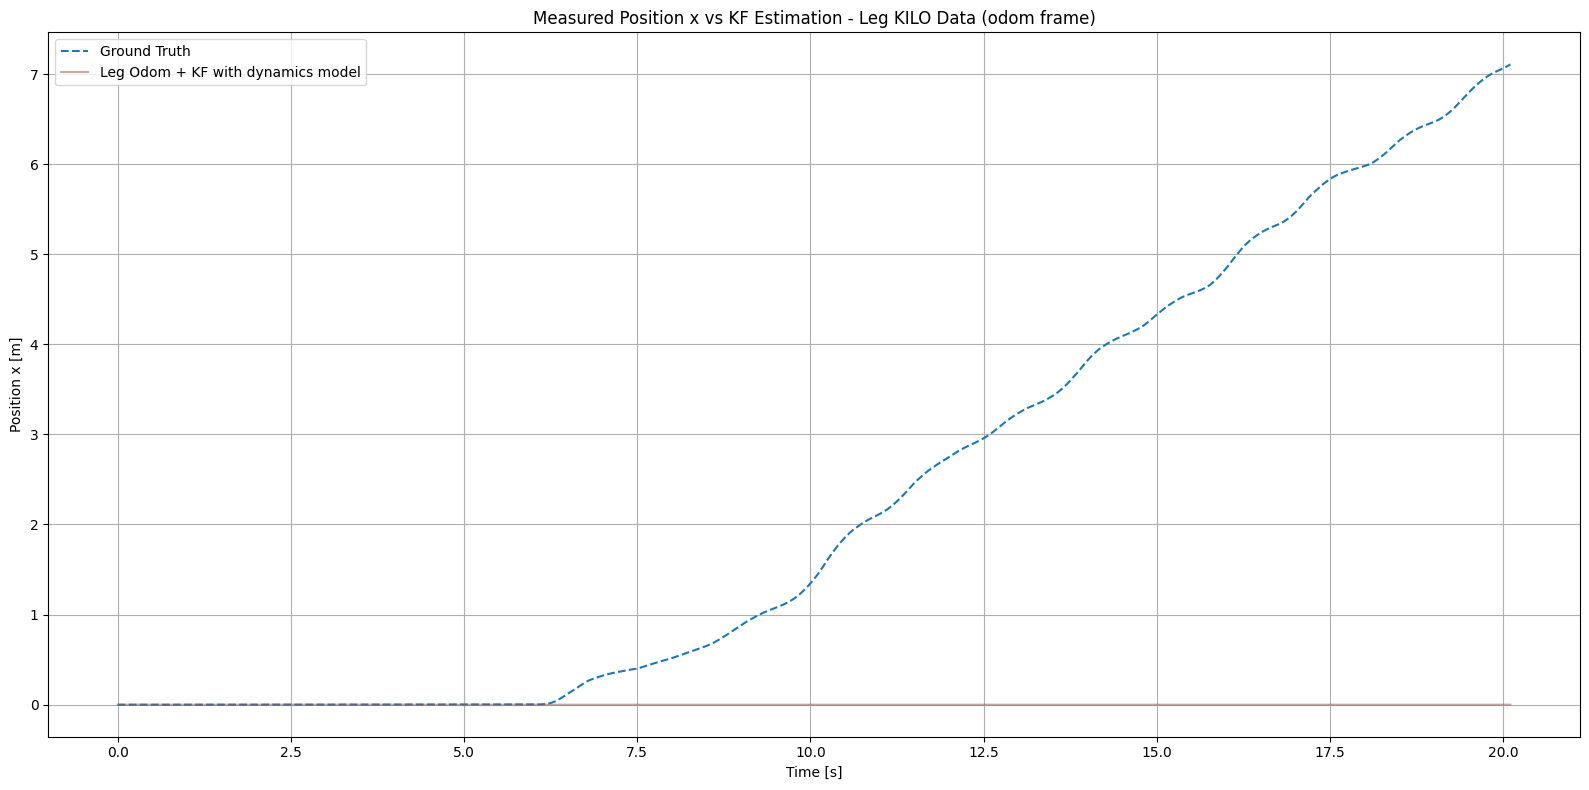

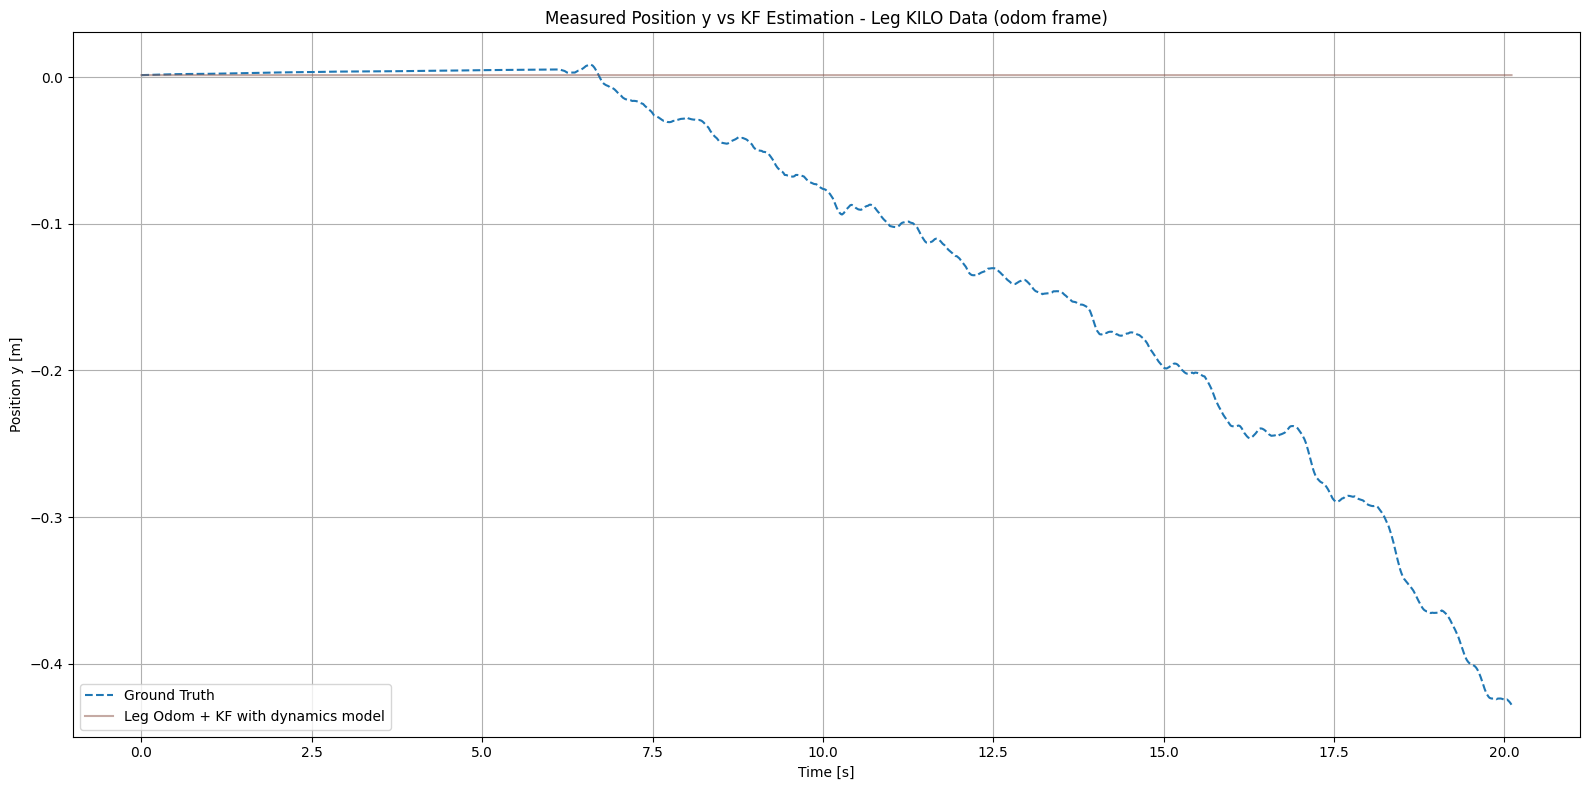

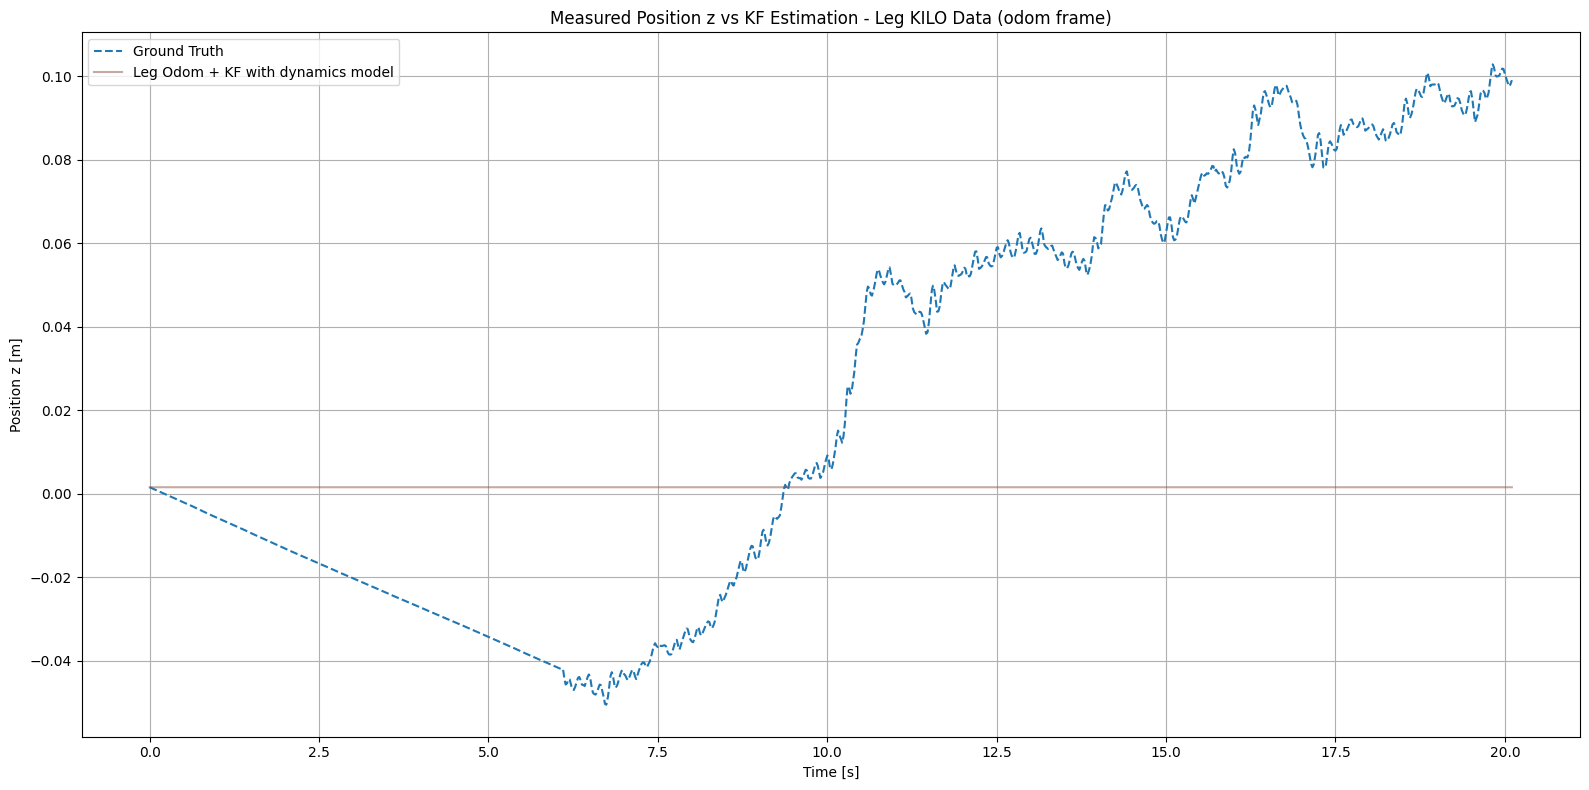

In [64]:
colors = ['#1f77b4', # gt
        # '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
time_state = leg_kilo_data["time_state"]
time_state -= time_state[0]

num_data_points = 10000

for i in range(len(dim)):
    gt_values = leg_kilo_data["base_pos_w"][:num_data_points, i:i+1]

    pred_values = [pos_update_w[:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=time_state[:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Position {dim[i]} [m]",
                            title=f"Measured Position {dim[i]} vs KF Estimation - Leg KILO Data (odom frame)",
                            colors=colors
                            )

### Compare ground truth vs my estimation

In [ ]:
# synchronize gt data points with rosbag

gt_timestamps = legkilo_reader.gt_timestamps
gt_positions = legkilo_reader.gt_positions
sensor_timestamps = leg_kilo_data["time_state"]

# derive gt_vel from gt_pos
gt_dt = np.diff(gt_timestamps)
gt_dp = np.diff(gt_positions, axis=0)
gt_vel = gt_dp / gt_dt[:, np.newaxis]
gt_vel_timestamps = (gt_timestamps[:-1] + gt_timestamps[1:]) / 2

t_start = sensor_timestamps[0]
t_end = sensor_timestamps[num_data_points - 1]

gt_mask = (gt_timestamps >= t_start) & (gt_timestamps <= t_end) # mask of timestamps in set range of sensor points
gt_vel_mask = (gt_vel_timestamps >= t_start) & (gt_vel_timestamps <= t_end)

gt_timestamps_crop = gt_timestamps[gt_mask]
gt_vel_timestamps_crop = gt_vel_timestamps[gt_vel_mask]

gt_pos_crop = gt_positions[gt_mask]
gt_vel_crop = gt_vel[gt_vel_mask]

indices = np.searchsorted(sensor_timestamps[:num_data_points], gt_timestamps_crop)
indices = np.clip(indices, 0, num_data_points - 1)
vel_indices = np.searchsorted(sensor_timestamps[:num_data_points], gt_vel_timestamps_crop)
vel_indices = np.clip(vel_indices, 0, num_data_points - 1)

diffs = np.abs(sensor_timestamps[indices] - gt_timestamps_crop)
vel_diffs = np.abs(sensor_timestamps[vel_indices] - gt_vel_timestamps_crop)
valid = diffs < 0.05
vel_valid = vel_diffs < 0.05
sensor_idx_synced = indices[valid]
sensor_vel_idx_synced = vel_indices[vel_valid]

gt_pos_synced = gt_pos_crop[valid]
gt_vel_synced = gt_vel_crop[vel_valid]
pos_est_synced = pos_update_w[sensor_idx_synced]
vel_est_synced = vel_update_w[sensor_vel_idx_synced]

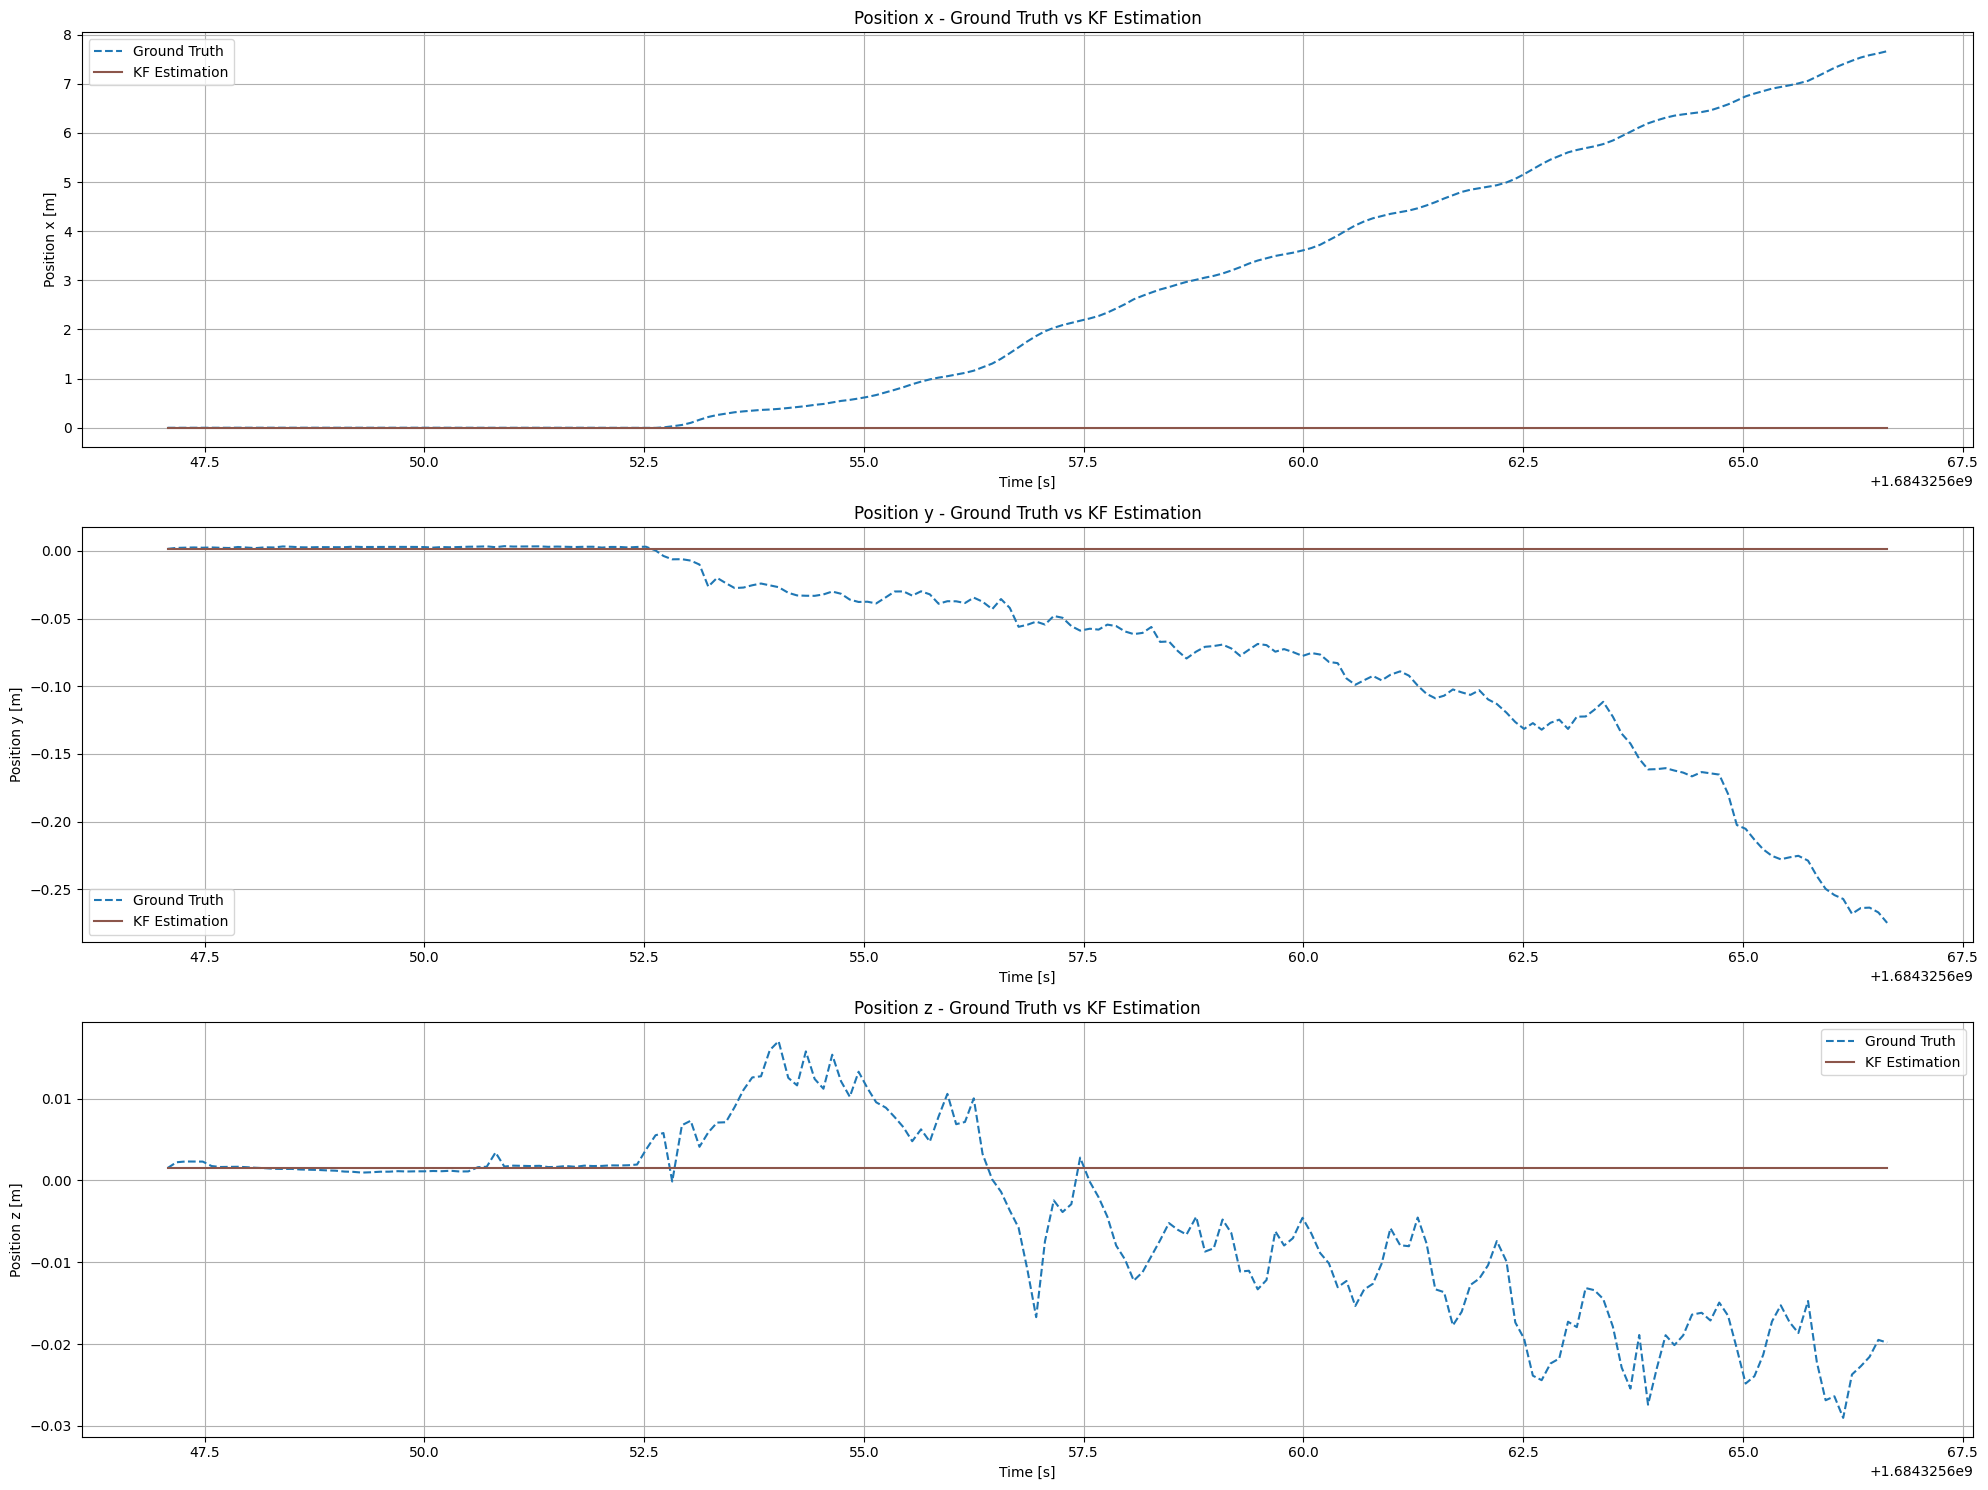

In [82]:
fig, axes = plt.subplots(3, 1, figsize=(20, 15))
dim = ["x", "y", "z"]

for i in range(3):
    axes[i].plot(gt_timestamps_crop[valid], gt_pos_synced[:, i], 
                 label="Ground Truth", linestyle="--", color="#1f77b4")
    axes[i].plot(gt_timestamps_crop[valid], pos_est_synced[:, i], 
                 label="KF Estimation", color="#8c564b")
    axes[i].set_ylabel(f"Position {dim[i]} [m]")
    axes[i].set_xlabel("Time [s]")
    axes[i].set_title(f"Position {dim[i]} - Ground Truth vs KF Estimation")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

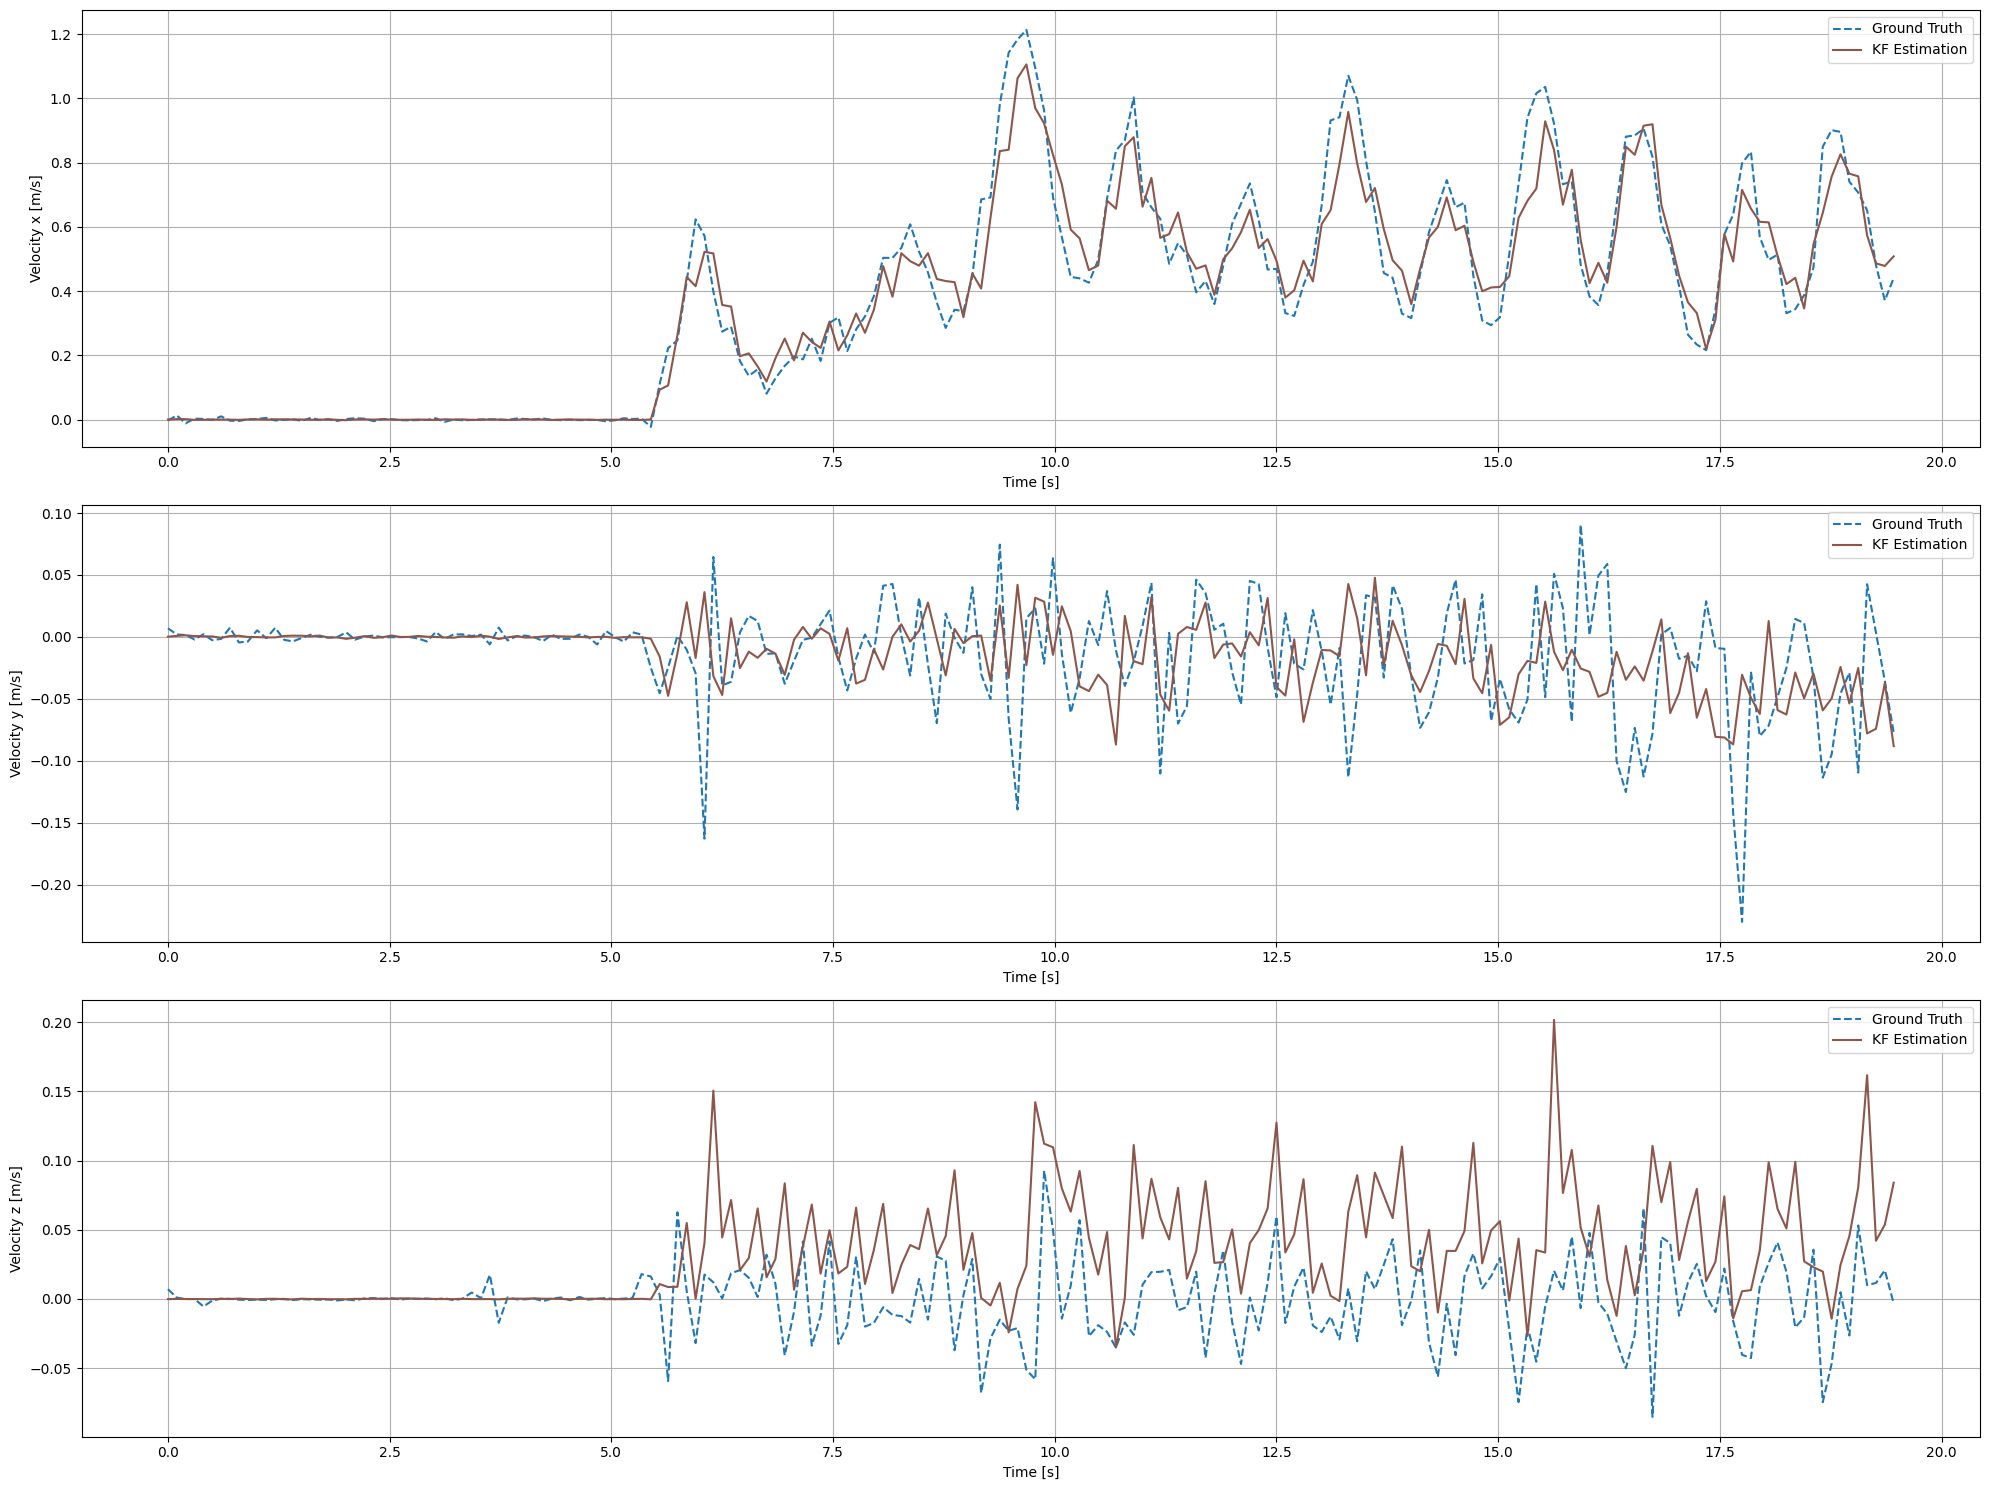

In [83]:
fig, axes = plt.subplots(3, 1, figsize=(20, 15))
dim = ["x", "y", "z"]
t_rel = gt_vel_timestamps_crop[vel_valid] - gt_vel_timestamps_crop[vel_valid][0]

for i in range(3):
    axes[i].plot(t_rel, gt_vel_synced[:, i], label="Ground Truth", linestyle="--", color="#1f77b4")
    axes[i].plot(t_rel, vel_est_synced[:, i], label="KF Estimation", color="#8c564b")
    axes[i].set_ylabel(f"Velocity {dim[i]} [m/s]")
    axes[i].set_xlabel("Time [s]")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#### Save estimation

In [49]:
result_dir="results/leg-kilo"
file_name="leg-kilo_Q-0.0001_R-1"
save_path = Path.cwd().parent / result_dir
save_path.mkdir(parents=True, exist_ok=True)

In [50]:
np.savez(f"{save_path}/{file_name}.npz", **results_leg_kilo_est)

In [51]:
results_leg_kilo_est = np.load(f"{save_path}/{file_name}.npz")